# Mental Health Work Interference Analyzer

**Data Management / MedTech Portfolio Project**

This project analyzes the **OSMI Mental Health in Tech Survey 2014** and develops two predictive models:

- **Full Model:** uses personal and workplace variables.
- **HR Model:** uses workplace variables only.

The goal is to estimate the probability that mental-health difficulties interfere with work while explicitly separating predictive performance from ethical usability.

> **Important:** This project is an educational decision-support prototype. It is not a diagnostic tool and must not be used for hiring, firing, promotion, or employee surveillance.

## 1. Research Questions

1. Which variables are associated with meaningful work interference?
2. How accurately can work interference be predicted?
3. How much performance is lost when sensitive personal variables are excluded?
4. Which workplace factors can HR teams ethically observe or improve?

In [23]:
# Optional installation for Google Colab:
# !pip install -q pandas numpy scipy matplotlib scikit-learn xgboost joblib

from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)

## 2. Load the Dataset

The notebook searches common local and Google Colab locations.  
In Colab, upload `survey.csv` using the Files panel if it is not already available.

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
candidate_paths = [
    Path("survey.csv"),
    Path("survey(1)(2).csv"),
    Path("/content/survey.csv"),
    Path("/content/survey(1)(2).csv"),
    Path("/content/drive/MyDrive/survey.csv"),
    Path("/content/drive/MyDrive/survey(1)(2).csv"),
    Path("/mnt/data/survey.csv"),
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "survey.csv was not found. Upload it to the Colab Files panel or place it next to this notebook."
    )

df = pd.read_csv(DATA_PATH)

print(f"Loaded from: {DATA_PATH}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Loaded from: /content/drive/MyDrive/survey(1)(2).csv
Rows: 1,259
Columns: 27


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


## 3. Initial Data Audit

In [26]:
print("Duplicate rows:", df.duplicated().sum())

audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)

display(audit.head(15))

Duplicate rows: 0


,dtype,missing_n,missing_pct,unique_values
comments,object,1095,86.97,160
state,object,515,40.91,45
work_interfere,object,264,20.97,4
self_employed,object,18,1.43,2
Gender,object,0,0.00,49
Timestamp,object,0,0.00,1246
Age,int64,0,0.00,53
family_history,object,0,0.00,2
treatment,object,0,0.00,2
no_employees,object,0,0.00,6


In [27]:
target_counts = df["work_interfere"].value_counts(dropna=False)
target_percentages = (
    df["work_interfere"]
    .value_counts(dropna=False, normalize=True)
    .mul(100)
    .round(2)
)

display(pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
}))

,Count,Percentage
work_interfere,,
Sometimes,465,36.93
NaN,264,20.97
Never,213,16.92
Rarely,173,13.74
Often,144,11.44


## 4. Data Cleaning

Cleaning decisions:

- Remove exact duplicate rows.
- Remove `comments` because it is highly sparse and unstructured.
- Remove `state` because it applies mainly to US respondents and is not used in the deployment model.
- Replace implausible ages with the median of plausible ages.
- Standardize gender labels.
- Impute missing `self_employed` values with the mode.
- Keep rows with missing target values for missingness analysis, then exclude them from supervised learning.

In [28]:
data = df.drop_duplicates().copy()

for column in ["comments", "state"]:
    if column in data.columns:
        data = data.drop(columns=column)

valid_age = data["Age"].between(15, 75)
median_age = data.loc[valid_age, "Age"].median()
invalid_age_count = int((~valid_age).sum())
data.loc[~valid_age, "Age"] = median_age

def clean_gender(value):
    text = str(value).strip().lower()

    male_labels = {
        "m", "male", "male-ish", "maile", "mal", "make",
        "msle", "mail", "cis male", "cis man", "man",
    }
    female_labels = {
        "f", "female", "femake", "female (cis)", "femail",
        "cis female", "cis-female/femme", "woman",
    }

    if text in male_labels or ("male" in text and "female" not in text):
        return "male"
    if text in female_labels or "female" in text or "woman" in text:
        return "female"
    return "non_binary"

data["Gender"] = data["Gender"].apply(clean_gender)

if data["self_employed"].isna().any():
    self_employed_mode = data["self_employed"].mode(dropna=True).iloc[0]
    data["self_employed"] = data["self_employed"].fillna(self_employed_mode)

print("Cleaned shape:", data.shape)
print("Implausible ages replaced:", invalid_age_count)
print("Median age used:", median_age)
display(data["Gender"].value_counts())

Cleaned shape: (1259, 25)
Implausible ages replaced: 8
Median age used: 31.0


,count
Gender,
male,993
female,251
non_binary,15


In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   self_employed              1259 non-null   object
 5   family_history             1259 non-null   object
 6   treatment                  1259 non-null   object
 7   work_interfere             995 non-null    object
 8   no_employees               1259 non-null   object
 9   remote_work                1259 non-null   object
 10  tech_company               1259 non-null   object
 11  benefits                   1259 non-null   object
 12  care_options               1259 non-null   object
 13  wellness_program           1259 non-null   object
 14  seek_hel

## 5. Target Missingness Analysis

The target contains missing responses. We test whether target non-response is associated with observed variables.

A significant association does not prove a specific missing-data mechanism, but it indicates that complete-case analysis may introduce selection bias.

In [30]:
data["missing_target"] = data["work_interfere"].isna().astype(int)
print(f"Missing target rate: {data['missing_target'].mean():.2%}")

def cramers_v_corrected(x, y):
    table = pd.crosstab(x.fillna("Missing"), y)
    if min(table.shape) < 2:
        return np.nan

    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape

    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    r_corr = r - ((r - 1) ** 2) / max(n - 1, 1)
    k_corr = k - ((k - 1) ** 2) / max(n - 1, 1)
    denominator = min(k_corr - 1, r_corr - 1)

    return np.sqrt(phi2_corr / denominator) if denominator > 0 else 0.0

results = []
categorical_features = [
    col for col in data.select_dtypes(include="object").columns
    if col != "work_interfere"
]

for feature in categorical_features:
    table = pd.crosstab(data[feature].fillna("Missing"), data["missing_target"])
    if min(table.shape) < 2:
        continue
    _, p_value, _, _ = chi2_contingency(table)
    results.append({
        "Feature": feature,
        "P-value": p_value,
        "Cramers_V": cramers_v_corrected(data[feature], data["missing_target"]),
    })

missingness_results = (
    pd.DataFrame(results)
    .sort_values(["Cramers_V", "P-value"], ascending=[False, True])
)

display(missingness_results.head(10))

Missing target rate: 20.97%


,Feature,P-value,Cramers_V
5,treatment,1.918357e-71,0.503122
4,family_history,2.537470e-17,0.237023
2,Country,3.304973e-04,0.178710
10,care_options,8.180754e-09,0.167373
15,mental_health_consequence,1.461931e-07,0.153069
14,leave,3.995496e-05,0.130714
9,benefits,1.219713e-05,0.128050
22,obs_consequence,3.598573e-05,0.113028
1,Gender,1.497934e-03,0.093534
16,phys_health_consequence,2.450307e-03,0.089254


### Interpretation

Approximately 21% of respondents did not answer the target question (`work_interfere`).

The missingness analysis indicates that non-response is associated with several observed variables, particularly previous treatment (Cramér's V = 0.50) and family history (0.24). Therefore, the missing target values are unlikely to be completely random.

Because the true target values are unknown, imputing them could introduce additional bias. Consequently, rows with missing target values are excluded from supervised model training, while this limitation is explicitly acknowledged.


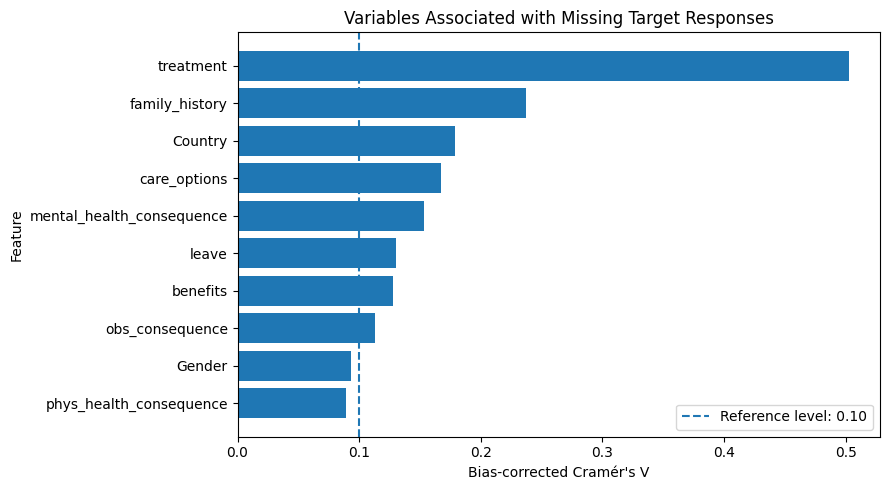

In [31]:
top_missingness = (
    missingness_results
    .dropna()
    .sort_values("Cramers_V", ascending=False)
    .head(10)
    .sort_values("Cramers_V")
)

plt.figure(figsize=(9, 5))

plt.barh(
    top_missingness["Feature"],
    top_missingness["Cramers_V"]
)

plt.axvline(
    x=0.10,
    linestyle="--",
    label="Reference level: 0.10"
)

plt.xlabel("Bias-corrected Cramér's V")
plt.ylabel("Feature")
plt.title("Variables Associated with Missing Target Responses")
plt.legend()
plt.tight_layout()

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
plt.savefig(
    FIGURES_DIR / "target_missingness_cramers_v.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [32]:
observed_age = data.loc[data["missing_target"] == 0, "Age"].dropna()
missing_age = data.loc[data["missing_target"] == 1, "Age"].dropna()

u_statistic, p_value = mannwhitneyu(
    observed_age,
    missing_age,
    alternative="two-sided",
)

print(f"Mann–Whitney U statistic: {u_statistic:.2f}")
print(f"P-value: {p_value:.4f}")

Mann–Whitney U statistic: 143685.00
P-value: 0.0186


### Missingness Interpretation

The true target values for non-respondents are unknown and cannot be reliably imputed without strong assumptions. Therefore, missing-target rows are excluded from supervised modelling, and potential selection bias is explicitly reported as a limitation.

## 6. Exploratory Data Analysis

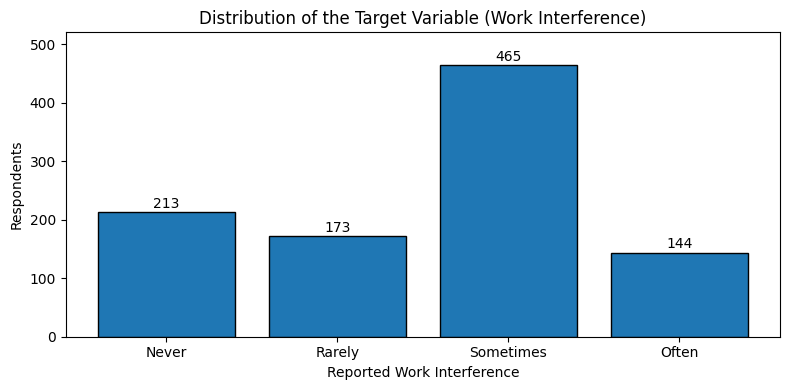

In [33]:
# Timestamp is not used as a predictive feature.
data = data.drop(columns=["Timestamp"], errors="ignore")

model_data = data.dropna(subset=["work_interfere"]).copy()
target_order = ["Never", "Rarely", "Sometimes", "Often"]

counts = (
    model_data["work_interfere"]
    .value_counts()
    .reindex(target_order)
)

plt.figure(figsize=(8, 4))

bars = plt.bar(
    counts.index,
    counts.values,
    edgecolor="black"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(counts.values) * 0.015,
        f"{int(height)}",
        ha="center",
        fontsize=10
    )

plt.ylim(0, max(counts.values) * 1.12)
plt.xlabel("Reported Work Interference")
plt.ylabel("Respondents")
plt.title("Distribution of the Target Variable (Work Interference)")
plt.tight_layout()

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
plt.savefig(
    FIGURES_DIR / "target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Interpretation

Most respondents reported that mental health sometimes interfered with their work.
The target classes are moderately imbalanced, with **"Sometimes"** representing the largest category.
This class imbalance should be considered when interpreting classification metrics and model performance.

Saved: figures/work_interference_by_treatment.png


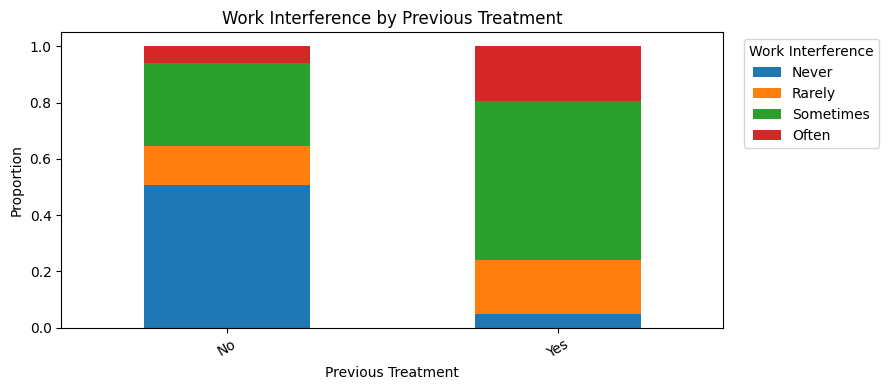

Saved: figures/work_interference_by_family_history.png


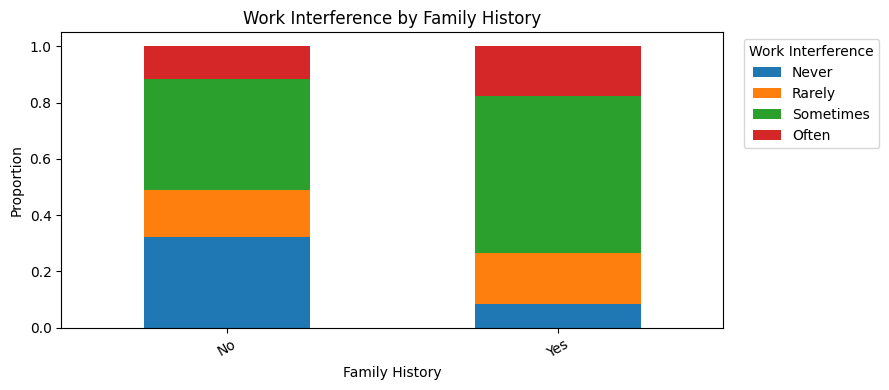

Saved: figures/work_interference_by_benefits.png


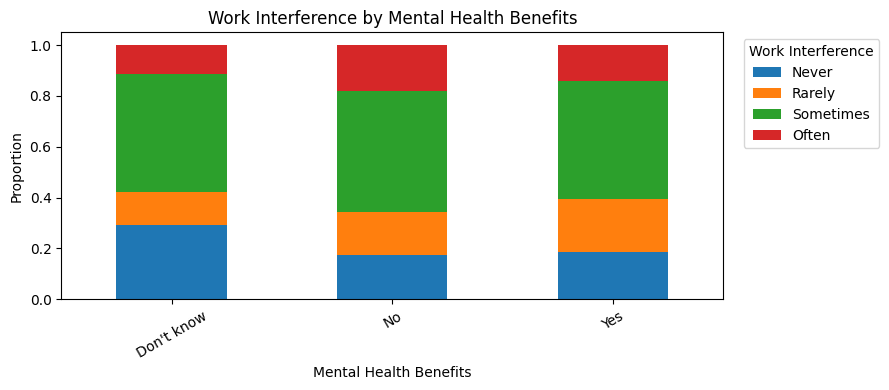

Saved: figures/work_interference_by_care_options.png


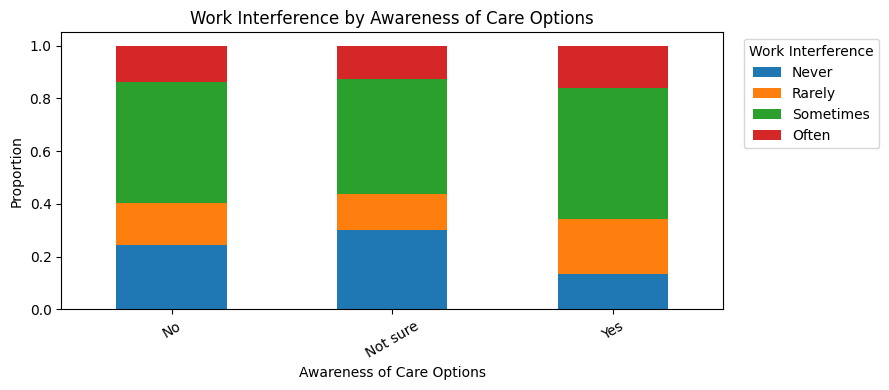

Saved: figures/work_interference_by_leave.png


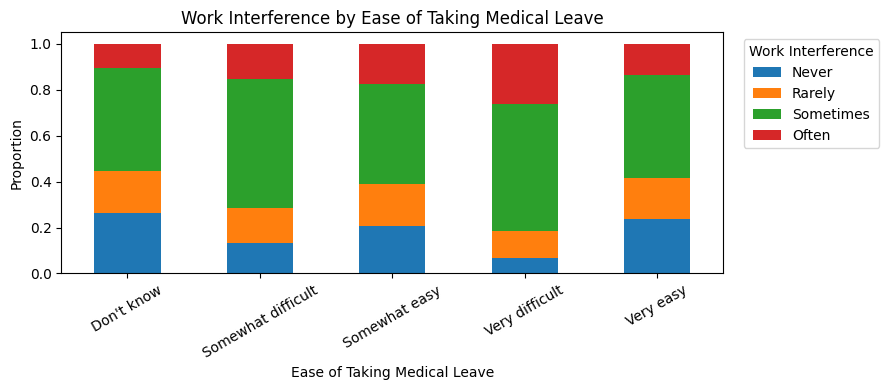

Saved: figures/work_interference_by_mental_health_consequence.png


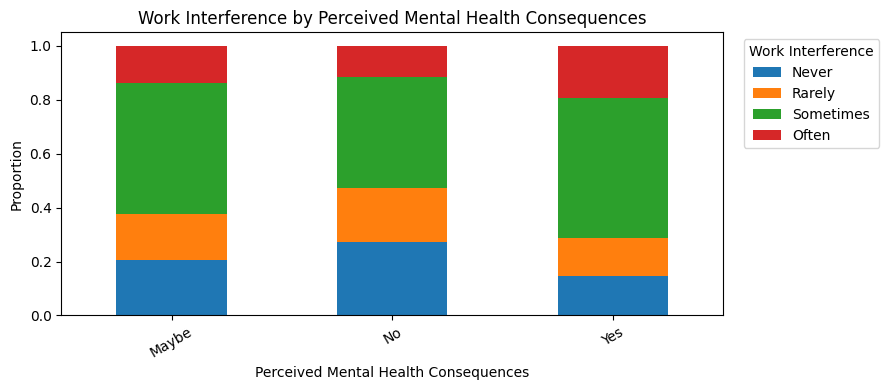

In [34]:
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

FEATURE_LABELS = {
    "treatment": "Previous Treatment",
    "family_history": "Family History",
    "benefits": "Mental Health Benefits",
    "care_options": "Awareness of Care Options",
    "leave": "Ease of Taking Medical Leave",
    "mental_health_consequence": "Perceived Mental Health Consequences",
}

def plot_stacked_proportions(
    frame,
    feature,
    target="work_interfere",
    save=True
):
    table = pd.crosstab(
        frame[feature],
        frame[target],
        normalize="index"
    )

    ordered_columns = [
        category
        for category in target_order
        if category in table.columns
    ]
    table = table.reindex(columns=ordered_columns)

    display_name = FEATURE_LABELS.get(
        feature,
        feature.replace("_", " ").title()
    )

    ax = table.plot(
        kind="bar",
        stacked=True,
        figsize=(9, 4)
    )

    ax.set_title(f"Work Interference by {display_name}")
    ax.set_xlabel(display_name)
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=30)

    ax.legend(
        title="Work Interference",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()

    if save:
        filename = FIGURES_DIR / f"work_interference_by_{feature}.png"
        plt.savefig(
            filename,
            dpi=300,
            bbox_inches="tight"
        )
        print(f"Saved: {filename}")

    plt.show()
    plt.close()

features_to_plot = [
    "treatment",
    "family_history",
    "benefits",
    "care_options",
    "leave",
    "mental_health_consequence",
]

for feature in features_to_plot:
    if feature in model_data.columns:
        plot_stacked_proportions(model_data, feature)

## 7. Define the Prediction Task

The four-level target is converted into a binary outcome:

- `0`: Never or Rarely
- `1`: Sometimes or Often

This formulation identifies respondents reporting meaningful work interference.

In [35]:
target_mapping = {
    "Never": 0,
    "Rarely": 0,
    "Sometimes": 1,
    "Often": 1,
}

model_data["target"] = model_data["work_interfere"].map(target_mapping)
model_data = model_data.dropna(subset=["target"]).copy()
model_data["target"] = model_data["target"].astype(int)

hr_features = [
    "benefits",
    "care_options",
    "wellness_program",
    "seek_help",
    "anonymity",
    "leave",
    "mental_health_consequence",
    "phys_health_consequence",
    "coworkers",
    "supervisor",
    "mental_vs_physical",
    "obs_consequence",
    "no_employees",
    "remote_work",
    "tech_company",
]

personal_features = [
    "Age",
    "Gender",
    "family_history",
    "treatment",
    "self_employed",
    "mental_health_interview",
    "phys_health_interview",
]

hr_features = [f for f in hr_features if f in model_data.columns]
personal_features = [f for f in personal_features if f in model_data.columns]
full_features = hr_features + personal_features

X_full = model_data[full_features].copy()
X_hr = model_data[hr_features].copy()
y = model_data["target"]

print(f"Training samples: {len(model_data)}")
print(f"Full model features: {len(full_features)}")
print(f"HR model features: {len(hr_features)}")

display(
    model_data["target"]
    .value_counts()
    .rename(index={1: "Meaningful", 0: "Low"})
    .rename_axis("Target")
    .to_frame("Count")
)

Training samples: 995
Full model features: 22
HR model features: 15


,Count
Target,
Meaningful,609
Low,386


## 8. Preprocessing Pipelines

Preprocessing is fitted inside the pipeline to reduce data leakage:

- Numerical features: median imputation and standardization.
- Categorical features: most-frequent imputation and one-hot encoding.

In [36]:
def make_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_preprocessor(X):
    numeric_columns = X.select_dtypes(include=np.number).columns.tolist()
    categorical_columns = X.select_dtypes(exclude=np.number).columns.tolist()

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_encoder()),
    ])

    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns),
    ])

    return preprocessor, numeric_columns, categorical_columns

preprocessor_full, num_cols_full, cat_cols_full = make_preprocessor(X_full)
preprocessor_hr, num_cols_hr, cat_cols_hr = make_preprocessor(X_hr)

## 9. Model Comparison

Models are evaluated using stratified 5-fold cross-validation.

Metrics:

- **ROC-AUC:** probability-ranking ability.
- **F1:** balance between precision and recall.
- **MCC:** balanced classification quality.

In [37]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        n_estimators=250,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scenarios = {
    "Full Model": (X_full, preprocessor_full),
    "HR Model": (X_hr, preprocessor_hr),
}

rows = []

for scenario_name, (X_input, preprocessor) in scenarios.items():
    for model_name, estimator in models.items():
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", estimator),
        ])

        scores = cross_validate(
            pipeline,
            X_input,
            y,
            cv=cv,
            scoring={
                "AUC": "roc_auc",
                "F1": "f1",
                "MCC": "matthews_corrcoef",
            },
            n_jobs=1,
        )

        rows.append({
            "Scenario": scenario_name,
            "Model": model_name,
            "AUC_mean": scores["test_AUC"].mean(),
            "AUC_std": scores["test_AUC"].std(),
            "F1_mean": scores["test_F1"].mean(),
            "F1_std": scores["test_F1"].std(),
            "MCC_mean": scores["test_MCC"].mean(),
            "MCC_std": scores["test_MCC"].std(),
        })

cv_results = pd.DataFrame(rows).sort_values(
    ["Scenario", "AUC_mean"],
    ascending=[True, False],
)

display(cv_results.round(3))

,Scenario,Model,AUC_mean,AUC_std,F1_mean,F1_std,MCC_mean,MCC_std
1,Full Model,Random Forest,0.758,0.031,0.778,0.029,0.390,0.080
0,Full Model,Logistic Regression,0.733,0.039,0.747,0.029,0.376,0.066
2,Full Model,XGBoost,0.728,0.032,0.774,0.022,0.361,0.060
4,HR Model,Random Forest,0.621,0.037,0.659,0.019,0.155,0.036
5,HR Model,XGBoost,0.600,0.024,0.716,0.022,0.156,0.045
3,HR Model,Logistic Regression,0.597,0.033,0.610,0.021,0.140,0.037


### Model Comparison Interpretation

The Full Random Forest achieved the strongest overall performance, with a mean ROC-AUC of 0.758, F1 score of 0.778, and MCC of 0.390.

The workplace-only HR Random Forest achieved a lower mean ROC-AUC of 0.621. This performance gap indicates that sensitive personal variables, particularly treatment and family history, contain substantial predictive information.

However, the HR Model intentionally excludes these sensitive variables. Therefore, its lower predictive performance represents an ethical trade-off in favor of privacy, fairness, and organizational actionability.

Although the HR XGBoost model achieved a higher F1 score, its lower ROC-AUC suggests weaker overall discrimination. Random Forest was therefore selected as the final deployment model for both scenarios.

Saved: figures/model_comparison_auc.png


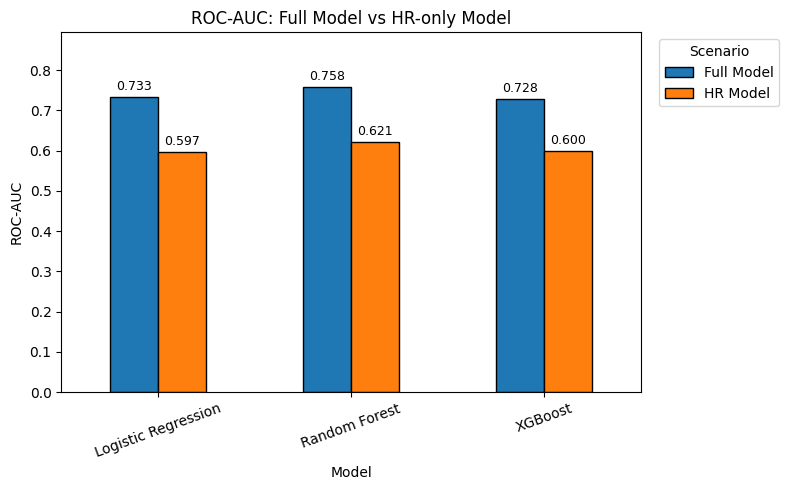

Saved: figures/model_comparison_f1.png


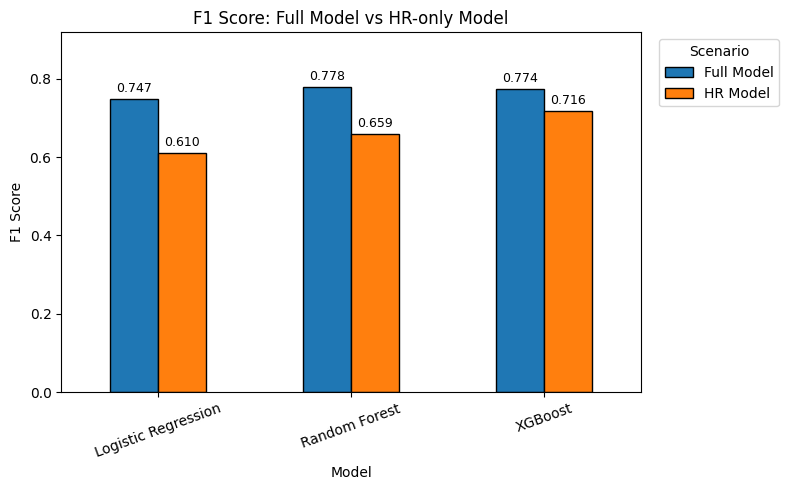

Saved: figures/model_comparison_mcc.png


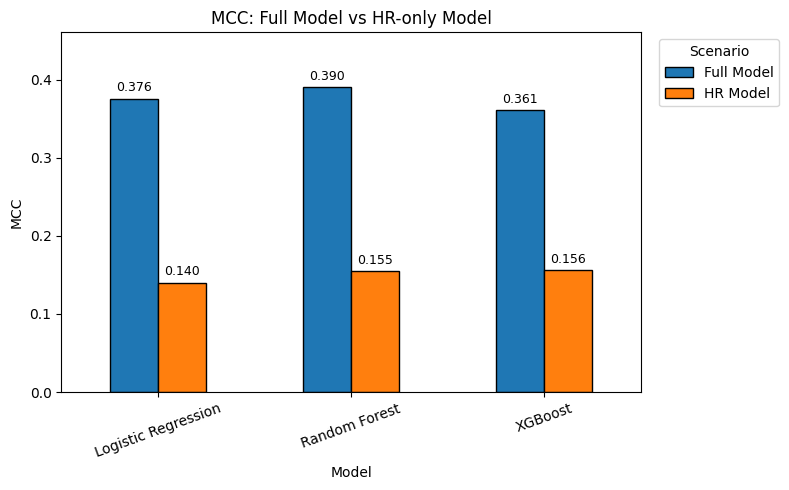

In [38]:
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

metrics_to_plot = [
    ("AUC_mean", "ROC-AUC", "model_comparison_auc.png"),
    ("F1_mean", "F1 Score", "model_comparison_f1.png"),
    ("MCC_mean", "MCC", "model_comparison_mcc.png"),
]

for metric_column, metric_title, filename in metrics_to_plot:
    pivot = cv_results.pivot(
        index="Model",
        columns="Scenario",
        values=metric_column,
    )

    ax = pivot.plot(
        kind="bar",
        figsize=(8, 5),
        edgecolor="black"
    )

    ax.set_title(f"{metric_title}: Full Model vs HR-only Model")
    ax.set_xlabel("Model")
    ax.set_ylabel(metric_title)
    ax.tick_params(axis="x", rotation=20)

    max_value = pivot.to_numpy().max()
    ax.set_ylim(0, max_value * 1.18)

    ax.legend(
        title="Scenario",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            padding=3,
            fontsize=9
        )

    plt.tight_layout()

    save_path = FIGURES_DIR / filename
    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    print(f"Saved: {save_path}")
    plt.show()
    plt.close()

## 10. Final Hold-out Evaluation

Random Forest is selected for deployment because it supports nonlinear relationships, probability estimates, and feature-importance analysis.

In [39]:
train_index, test_index = train_test_split(
    model_data.index,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_full_train = X_full.loc[train_index]
X_full_test = X_full.loc[test_index]
X_hr_train = X_hr.loc[train_index]
X_hr_test = X_hr.loc[test_index]
y_train = y.loc[train_index]
y_test = y.loc[test_index]

rf_full = Pipeline([
    ("preprocessor", preprocessor_full),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

rf_hr = Pipeline([
    ("preprocessor", preprocessor_hr),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

rf_full.fit(X_full_train, y_train)
rf_hr.fit(X_hr_train, y_train)

holdout_rows = []
holdout_predictions = {}

for name, pipeline, X_test in [
    ("Full Model", rf_full, X_full_test),
    ("HR Model", rf_hr, X_hr_test),
]:
    probability = pipeline.predict_proba(X_test)[:, 1]
    prediction = pipeline.predict(X_test)

    holdout_predictions[name] = (probability, prediction)
    holdout_rows.append({
        "Scenario": name,
        "ROC_AUC": roc_auc_score(y_test, probability),
        "F1": f1_score(y_test, prediction),
        "MCC": matthews_corrcoef(y_test, prediction),
    })

holdout_results = pd.DataFrame(holdout_rows)
display(holdout_results.round(3))

,Scenario,ROC_AUC,F1,MCC
0,Full Model,0.813,0.790,0.444
1,HR Model,0.595,0.656,0.076


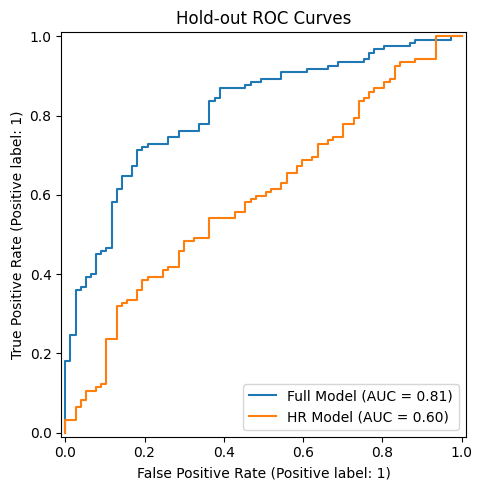

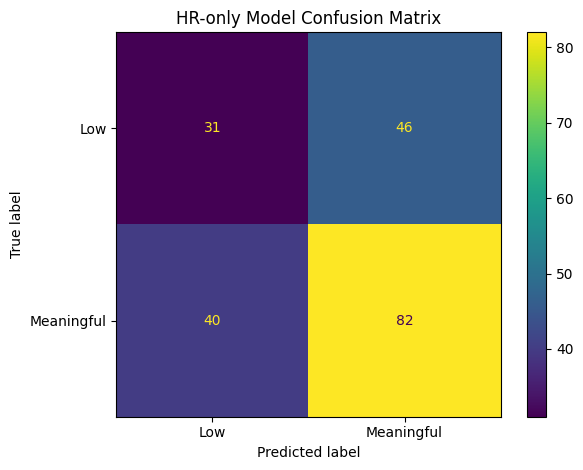

HR-only Model Classification Report
                         precision    recall  f1-score   support

       Low interference       0.44      0.40      0.42        77
Meaningful interference       0.64      0.67      0.66       122

               accuracy                           0.57       199
              macro avg       0.54      0.54      0.54       199
           weighted avg       0.56      0.57      0.56       199



In [40]:
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

plt.figure(figsize=(7, 5))
axis = plt.gca()

for name, (probability, _) in holdout_predictions.items():
    RocCurveDisplay.from_predictions(
        y_test,
        probability,
        name=name,
        ax=axis,
    )

plt.title("Hold-out ROC Curves")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "holdout_roc_curves.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

ConfusionMatrixDisplay.from_predictions(
    y_test,
    holdout_predictions["HR Model"][1],
    display_labels=["Low", "Meaningful"],
)
plt.title("HR-only Model Confusion Matrix")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "hr_model_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

print("HR-only Model Classification Report")
print(classification_report(
    y_test,
    holdout_predictions["HR Model"][1],
    target_names=["Low interference", "Meaningful interference"],
))

## 11. Feature Importance

Random Forest feature importances are aggregated from one-hot encoded variables back to their original feature names.

> Feature importance is predictive, not causal.

In [41]:
final_full_model = Pipeline([
    ("preprocessor", preprocessor_full),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

final_hr_model = Pipeline([
    ("preprocessor", preprocessor_hr),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

final_full_model.fit(X_full, y)
final_hr_model.fit(X_hr, y)

def aggregate_feature_importance(pipeline, numeric_columns, categorical_columns):
    preprocessor = pipeline.named_steps["preprocessor"]
    model = pipeline.named_steps["model"]

    names = list(numeric_columns)

    if categorical_columns:
        encoder = (
            preprocessor
            .named_transformers_["categorical"]
            .named_steps["onehot"]
        )
        names.extend(
            encoder.get_feature_names_out(categorical_columns).tolist()
        )

    details = pd.DataFrame({
        "transformed_feature": names,
        "importance": model.feature_importances_,
    })

    def map_original(name):
        if name in numeric_columns:
            return name
        matches = [
            column for column in categorical_columns
            if name.startswith(f"{column}_")
        ]
        return max(matches, key=len) if matches else name

    details["feature"] = details["transformed_feature"].apply(map_original)

    return (
        details
        .groupby("feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )

full_importance = aggregate_feature_importance(
    final_full_model,
    num_cols_full,
    cat_cols_full,
)

hr_importance = aggregate_feature_importance(
    final_hr_model,
    num_cols_hr,
    cat_cols_hr,
)

print("Top Full Model Features")
display(full_importance.head(12))

print("Top HR Model Features")
display(hr_importance.head(12))

Top Full Model Features


,feature,importance
20,treatment,0.320706
6,family_history,0.089919
7,leave,0.055897
0,Age,0.052269
11,no_employees,0.045837
8,mental_health_consequence,0.041235
16,seek_help,0.034387
10,mental_vs_physical,0.033946
3,benefits,0.032011
1,Gender,0.028549


Top HR Model Features


,feature,importance
4,leave,0.121944
7,no_employees,0.107517
5,mental_health_consequence,0.093687
6,mental_vs_physical,0.077615
11,seek_help,0.074002
2,care_options,0.061315
8,obs_consequence,0.060830
3,coworkers,0.057809
1,benefits,0.056975
0,anonymity,0.054019


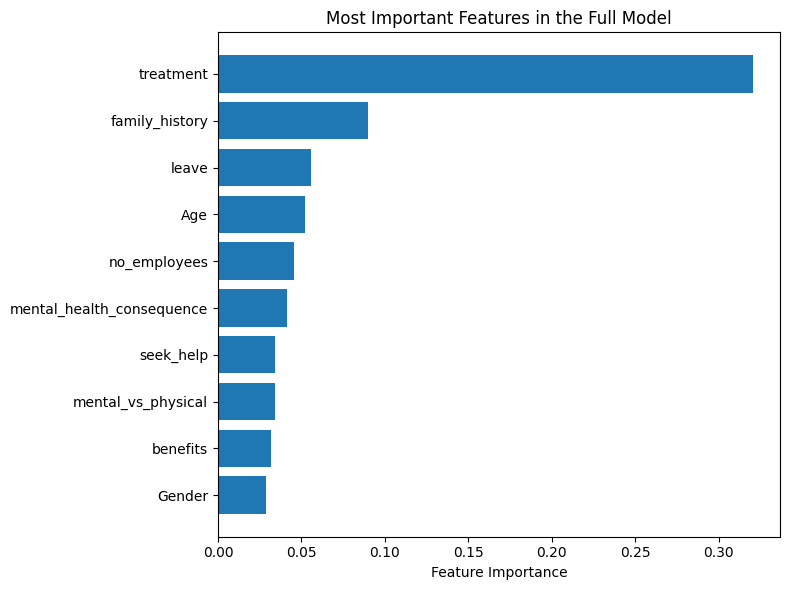

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.barh(
    full_importance["feature"].head(10),
    full_importance["importance"].head(10)
)

plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Most Important Features in the Full Model")

plt.tight_layout()
plt.savefig("figures/full_model_feature_importance.png", dpi=300)
plt.show()

Saved: figures/hr_model_feature_importance.png


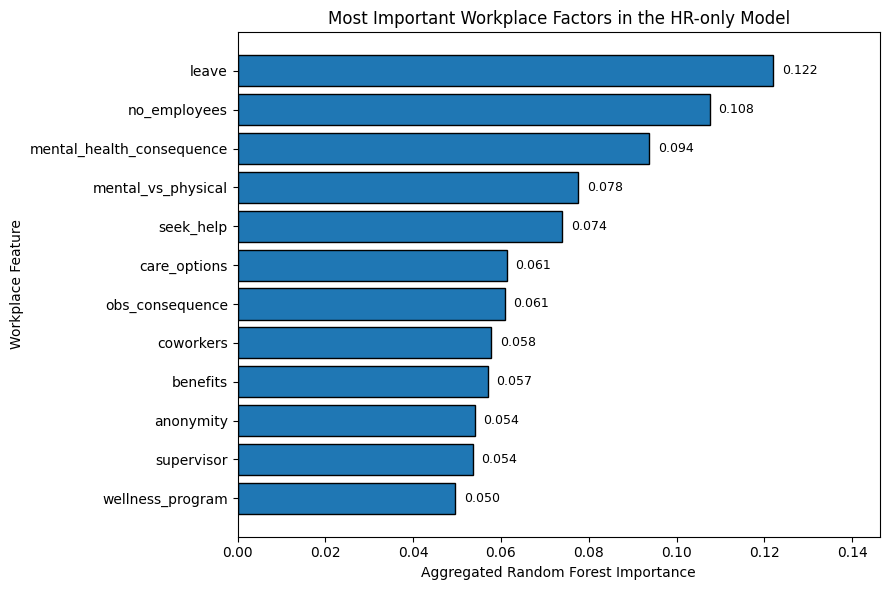

In [43]:
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

top_hr = (
    hr_importance
    .head(12)
    .sort_values("importance")
)

plt.figure(figsize=(9, 6))

bars = plt.barh(
    top_hr["feature"],
    top_hr["importance"],
    edgecolor="black"
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=9
    )

plt.xlabel("Aggregated Random Forest Importance")
plt.ylabel("Workplace Feature")
plt.title("Most Important Workplace Factors in the HR-only Model")
plt.xlim(0, top_hr["importance"].max() * 1.20)
plt.tight_layout()

save_path = FIGURES_DIR / "hr_model_feature_importance.png"
plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved: {save_path}")
plt.show()
plt.close()

## 12. Ethical Interpretation

The Full Model is expected to outperform the HR Model because sensitive personal variables contain strong predictive information.

However, HR teams should not use treatment history, family medical history, or similar variables for individual-level screening. The HR Model intentionally accepts lower performance to prioritize:

- privacy,
- fairness,
- reduced discrimination risk,
- organizational accountability,
- and actionability.

### Appropriate use

- Aggregate policy evaluation
- Educational demonstrations
- Identifying organizational support gaps

### Inappropriate use

- Medical diagnosis
- Hiring, firing, promotion, or disciplinary decisions
- Individual employee ranking or surveillance
- Replacing professional mental-health assessment

In [44]:
best_full_auc = cv_results.loc[
    cv_results["Scenario"] == "Full Model",
    "AUC_mean",
].max()

best_hr_auc = cv_results.loc[
    cv_results["Scenario"] == "HR Model",
    "AUC_mean",
].max()

print(f"Best Full Model CV AUC: {best_full_auc:.3f}")
print(f"Best HR Model CV AUC:   {best_hr_auc:.3f}")
print(f"AUC performance gap:    {best_full_auc - best_hr_auc:.3f}")

Best Full Model CV AUC: 0.758
Best HR Model CV AUC:   0.621
AUC performance gap:    0.136


## 13. Export Deployment Artifacts

The exported model files include preprocessing and prediction logic in a single pipeline.

In [45]:
OUTPUT_DIR = Path("artifacts")
OUTPUT_DIR.mkdir(exist_ok=True)

joblib.dump(final_full_model, OUTPUT_DIR / "model_full.pkl", compress=3)
joblib.dump(final_hr_model, OUTPUT_DIR / "model_hr.pkl", compress=3)

feature_metadata = {
    "full_features": full_features,
    "hr_features": hr_features,
    "num_cols": num_cols_full,
    "cat_cols": cat_cols_full,
    "num_cols_hr": num_cols_hr,
    "cat_cols_hr": cat_cols_hr,
}

with open(
    OUTPUT_DIR / "feature_names.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(feature_metadata, file, indent=2)

feature_values = {}

for column in full_features:
    if column == "Age":
        feature_values[column] = sorted(
            model_data[column]
            .dropna()
            .astype(float)
            .unique()
            .tolist()
        )
    else:
        feature_values[column] = sorted(
            model_data[column]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

with open(
    OUTPUT_DIR / "feature_values.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(feature_values, file, indent=2)

# Dashboard-ready Power BI dataset.
power_bi_data = model_data.copy()
power_bi_data["target_label"] = power_bi_data["target"].map({
    0: "Low",
    1: "Meaningful"
})

power_bi_data.to_csv(
    OUTPUT_DIR / "mental_health_power_bi.csv",
    index=False
)

# Compact model-comparison table for Power BI or the presentation.
cv_results.round(4).to_csv(
    OUTPUT_DIR / "model_comparison_results.csv",
    index=False
)

print("Exported files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print("-", path)

Exported files:
- artifacts/feature_names.json
- artifacts/feature_values.json
- artifacts/mental_health_power_bi.csv
- artifacts/model_comparison_results.csv
- artifacts/model_full.pkl
- artifacts/model_hr.pkl


## 14. Conclusions

1. Work interference can be predicted moderately well from the OSMI survey.
2. Sensitive personal history contributes important predictive information.
3. A workplace-only model is less accurate but more ethically suitable for an HR-oriented prototype.
4. Benefits, care options, leave accessibility, disclosure culture, and supervisory support are key organizational variables.
5. Predictive associations must not be interpreted as causal effects.

## Limitations

- The survey is from 2014.
- The sample is self-selected and technology-sector focused.
- The target is self-reported.
- The four-level target was simplified into a binary outcome.
- Missing target responses may introduce selection bias.
- Cross-sectional data cannot establish causality.
- The tool must not be used for individual employment decisions.

## Future Work

- Validate on newer OSMI survey waves.
- Assess probability calibration.
- Compare binary, ordinal, and multiclass target formulations.
- Conduct subgroup fairness analysis when sample sizes are sufficient.
- Explore longitudinal or causal designs for policy evaluation.

## 15. Submission Checklist

Before submission:

1. Run **Runtime → Run all** once from a fresh Colab session.
2. Confirm that no red error output remains.
3. Download the `artifacts/` and `figures/` folders.
4. Submit the executed notebook, `mental_health_power_bi.csv`, Power BI file, and presentation.
5. In the presentation, emphasize:
   - 20.97% missing target responses and possible selection bias;
   - Random Forest as the strongest overall model;
   - Full Model ROC-AUC ≈ 0.758 versus HR-only Model ROC-AUC ≈ 0.621;
   - the privacy–performance trade-off;
   - feature importance is predictive, not causal.